In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras.optimizers import Adam 
import matplotlib.pyplot as plt

#Random seed setup
import random
SEED_VALUE = 42
os.environ['PYTHONHASHSEED'] = str(SEED_VALUE)
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)


#Configuration
PROCESSED_DATA_PATH = '../data/processed/train_FD001_processed.csv'
MODEL_SAVE_PATH = '../models/best_rul_gru_model.h5' 
WINDOW_SIZE = 50           
RUL_CLIPPING_VALUE = 100   

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

In [2]:
#Data Loading
try:
    df = pd.read_csv(PROCESSED_DATA_PATH)
    print(f"Data loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: Processed data file not found at {PROCESSED_DATA_PATH}. Check Milestone 1 output.")
    raise

#Feature Engineering
print(f"\nApplying RUL Clipping at {RUL_CLIPPING_VALUE} cycles...")
df['RUL_Clipped'] = df['RUL'].clip(upper=RUL_CLIPPING_VALUE)

#Define the features to be used in the GRU
FEATURE_COLUMNS = [col for col in df.columns if col not in ['unit_number', 'time_in_cycles', 'RUL', 'RUL_Clipped']]
TARGET_COLUMN = 'RUL_Clipped'

#Function to generate sequences for each engine unit
def generate_sequences(df, window_size, feature_cols, target_col):
    X, y, groups = [], [], []
    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit]
        features = unit_data[feature_cols].values
        target = unit_data[target_col].values
        unit_groups = unit_data['unit_number'].values
        
        for i in range(len(unit_data) - window_size + 1):
            X.append(features[i : i + window_size])
            y.append(target[i + window_size - 1]) 
            groups.append(unit_groups[i + window_size - 1])
            
    return np.array(X), np.array(y), np.array(groups)

X, y, groups = generate_sequences(df, WINDOW_SIZE, FEATURE_COLUMNS, TARGET_COLUMN)
print(f"Sequences generated successfully with WINDOW_SIZE={WINDOW_SIZE}.")
print(f"X shape: {X.shape}, y shape: {y.shape}, Groups shape: {groups.shape}")

Data loaded successfully. Shape: (20631, 23)

Applying RUL Clipping at 100 cycles...
Sequences generated successfully with WINDOW_SIZE=50.
X shape: (15731, 50, 20), y shape: (15731,), Groups shape: (15731,)


In [3]:
#Unit-Based Data Splitting 
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_full, X_test = X[train_idx], X[test_idx]
y_train_full, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42) 
train_idx, val_idx = next(gss_val.split(X_train_full, y_train_full, groups=groups_train))

X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

print(f"\nTraining samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}, Testing samples: {X_test.shape[0]}")


Training samples: 10681, Validation samples: 1960, Testing samples: 3090


In [4]:
#Build the Optimized GRU Model
def build_gru_model(timesteps, features):
    optimizer = Adam(learning_rate=0.0005) 
    
    model = Sequential([
        #First GRU layer
        GRU(128, input_shape=(timesteps, features), return_sequences=True),
        Dropout(0.3),
        
        #Second GRU layer
        GRU(64, return_sequences=False),
        Dropout(0.3),
        
        #Dense layers for consolidation
        Dense(32, activation='relu'),
        Dense(10, activation='relu'),
        
        #Output layer for RUL prediction
        Dense(1) 
    ])

    #Compile with RMSE metric
    model.compile(optimizer=optimizer, 
                  loss='mse', 
                  metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'), 'mae'])
    return model

model = build_gru_model(X_train.shape[1], X_train.shape[2])
model.summary()

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50, 128)        │        57,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,269 (379.96 KB)

 Trainable params: 97,269 (379.96 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Train the Model

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, mode='min', verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=150, 
    batch_size=64,
    callbacks=[early_stop, model_checkpoint],
    verbose=1
)

Epoch 1/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 4251.9834 - mae: 56.9535 - rmse: 64.8945
Epoch 1: val_loss improved from None to 1157.70276, saving model to ../models/best_rul_gru_model.h5


167/167 ━━━━━━━━━━━━━━━━━━━━ 25s 119ms/step - loss: 2979.1375 - mae: 46.7184 - rmse: 54.5815 - val_loss: 1157.7028 - val_mae: 30.8606 - val_rmse: 34.0250
Epoch 2/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 1138.8884 - mae: 29.6871 - rmse: 33.7455
Epoch 2: val_loss improved from 1157.70276 to 1116.58557, saving model to ../models/best_rul_gru_model.h5


167/167 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 1156.8741 - mae: 30.0596 - rmse: 34.0129 - val_loss: 1116.5856 - val_mae: 29.8112 - val_rmse: 33.4153
Epoch 3/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 1129.2333 - mae: 29.4858 - rmse: 33.5996
Epoch 3: val_loss improved from 1116.58557 to 858.47620, saving model to ../models/best_rul_gru_model.h5


167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - loss: 1139.1714 - mae: 29.8416 - rmse: 33.7516 - val_loss: 858.4762 - val_mae: 26.5463 - val_rmse: 29.2998
Epoch 4/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 599.1386 - mae: 20.5378 - rmse: 24.2622
Epoch 4: val_loss improved from 858.47620 to 80.41550, saving model to ../models/best_rul_gru_model.h5


167/167 ━━━━━━━━━━━━━━━━━━━━ 22s 134ms/step - loss: 383.1389 - mae: 15.5942 - rmse: 19.5739 - val_loss: 80.4155 - val_mae: 6.8915 - val_rmse: 8.9675
Epoch 5/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 142.5562 - mae: 9.1754 - rmse: 11.9346
Epoch 5: val_loss improved from 80.41550 to 73.91920, saving model to ../models/best_rul_gru_model.h5


...

167/167 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 120.3817 - mae: 8.4049 - rmse: 10.9719 - val_loss: 72.3544 - val_mae: 6.2543 - val_rmse: 8.5061
Epoch 7/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 125.3458 - mae: 8.5651 - rmse: 11.1917
Epoch 7: val_loss improved from 72.35441 to 53.84652, saving model to ../models/best_rul_gru_model.h5


167/167 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 118.8621 - mae: 8.3043 - rmse: 10.9024 - val_loss: 53.8465 - val_mae: 4.9667 - val_rmse: 7.3380
Epoch 8/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 113.0782 - mae: 8.1175 - rmse: 10.6324
Epoch 8: val_loss improved from 53.84652 to 52.56406, saving model to ../models/best_rul_gru_model.h5


167/167 ━━━━━━━━━━━━━━━━━━━━ 24s 141ms/step - loss: 110.3926 - mae: 7.9853 - rmse: 10.5068 - val_loss: 52.5641 - val_mae: 5.0038 - val_rmse: 7.2501
Epoch 9/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 110.7377 - mae: 7.9480 - rmse: 10.5228
Epoch 9: val_loss improved from 52.56406 to 51.84164, saving model to ../models/best_rul_gru_model.h5


167/167 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - loss: 109.0105 - mae: 7.8794 - rmse: 10.4408 - val_loss: 51.8416 - val_mae: 4.9972 - val_rmse: 7.2001
Epoch 10/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 110.6532 - mae: 7.9388 - rmse: 10.5182
Epoch 10: val_loss did not improve from 51.84164
167/167 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - loss: 108.9262 - mae: 7.8558 - rmse: 10.4368 - val_loss: 60.4492 - val_mae: 5.5989 - val_rmse: 7.7749
Epoch 11/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 108.5841 - mae: 7.8983 - rmse: 10.4185
Epoch 11: val_loss did not improve from 51.84164
167/167 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - loss: 106.5647 - mae: 7.8143 - rmse: 10.3230 - val_loss: 65.2862 - val_mae: 5.7902 - val_rmse: 8.0800
Epoch 12/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 115.1715 - mae: 8.1044 - rmse: 10.7291
Epoch 12: val_loss did not improve from 51.84164
167/167 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step - loss: 108.2974 - mae: 7.8423 - rmse: 10.4066 - val_los

167/167 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step - loss: 101.5699 - mae: 7.5252 - rmse: 10.0782 - val_loss: 50.7615 - val_mae: 4.7734 - val_rmse: 7.1247
Epoch 16/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 101.1733 - mae: 7.5561 - rmse: 10.0577
Epoch 16: val_loss did not improve from 50.76152
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - loss: 99.7510 - mae: 7.4642 - rmse: 9.9875 - val_loss: 56.9894 - val_mae: 5.2569 - val_rmse: 7.5491
Epoch 17/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 100.8843 - mae: 7.5016 - rmse: 10.0437
Epoch 17: val_loss did not improve from 50.76152
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 99.2029 - mae: 7.4442 - rmse: 9.9601 - val_loss: 59.2562 - val_mae: 5.3727 - val_rmse: 7.6978
Epoch 18/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 99.1979 - mae: 7.4796 - rmse: 9.9579
Epoch 18: val_loss did not improve from 50.76152
167/167 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step - loss: 96.9995 - mae: 7.3778 - rmse: 9.8488 - val_loss: 63.30

In [6]:
#Evaluate Model Performance

#Define custom objects to fix the HDF5 loading error
custom_objects = {
    'rmse': tf.keras.metrics.RootMeanSquaredError(name='rmse'), 
    'mse': tf.keras.losses.MeanSquaredError(),
    'relu': tf.keras.activations.relu
}

#Load the best model saved by the checkpoint
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH, custom_objects=custom_objects)

loss, rmse, mae = best_model.evaluate(X_test, y_test, verbose=1)
test_variance = np.var(y_test)
R2 = 1 - (loss / test_variance)

print(f"\nFinal Test Loss (MSE): {loss:.4f}")
print(f"Final Test RMSE: {rmse:.4f}")
print(f"Final Test MAE: {mae:.4f}")
print(f"Final Test R² Score: {R2:.4f}")

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 50.5440 - mean_absolute_error: 4.9010 - rmse: 7.1094

Final Test Loss (MSE): 50.5440
Final Test RMSE: 7.1094
Final Test MAE: 4.9010
Final Test R² Score: 0.9550


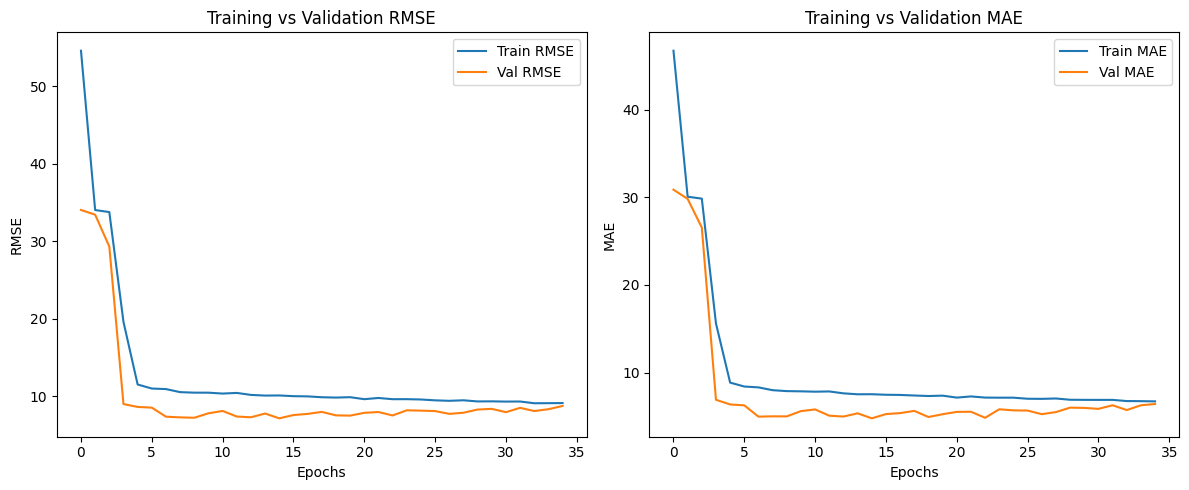

✅ Milestone 2 Optimization Complete!


In [7]:
#Visualize Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['rmse'], label='Train RMSE')
plt.plot(history.history['val_rmse'], label='Val RMSE')
plt.title('Training vs Validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

print("✅ Milestone 2 Optimization Complete!")